In [1]:
import pandas as pd        
import numpy as np        
import matplotlib.pyplot as plt  
import seaborn as sns      

In [2]:
df = pd.read_csv('module3_4_full_demo_dataset(mid project).csv')
df.head()

,transaction_date,customer_id,region,product_category,units_sold,unit_price,revenue,high_value
0,2024-02-10 00:00:00,2167,West,Beauty,5,20,103.512187,0
1,2024-03-16 00:00:00,2091,north,Clothng,1,60,24.896229,0
2,2024-09-25 00:00:00,2577,NaN,Home,13,40,533.647537,0
3,2024-12-21 00:00:00,1799,north,Clothng,2,40,115.121555,0
4,2024-08-08 00:00:00,2394,West,Beauty,8,40,305.988201,0


In [3]:

df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip().str.lower()
df_clean = df_clean.drop_duplicates()
df_clean = df_clean.dropna(subset=["transaction_date", "customer_id"])

categorical_cols = ["region", "product_category"]
for col in categorical_cols:
    df_clean[col] = df_clean[col].fillna("Unknown")

numeric_cols = ["units_sold", "unit_price", "revenue"]

for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce")
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())


df_clean["region"] = (
    df_clean["region"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.title()
)

df_clean["product_category"] = (
    df_clean["product_category"]
    .astype(str)
    .str.replace(r"\s+", " ", regex=True)
    .str.replace("\xa0", " ", regex=False)
    .str.strip()
    .str.title()
)

product_map = {
    "Clothng": "Clothing",
    "Cloth": "Clothing",
    "Elec": "Electronics",
    "Electronic": "Electronics",
    "Homegoods": "Home",
    "Home Goods": "Home",
    "Grocerie": "Groceries",
    "Grocery": "Groceries"
}

region_map = {
    "North East": "Northeast",
    "Northeast ": "Northeast",
    "South East": "Southeast",
    "Mid West": "Midwest",
    "West ": "West"
}

df_clean["product_category"] = df_clean["product_category"].replace(product_map)
df_clean["region"] = df_clean["region"].replace(region_map)

df_clean["transaction_date"] = pd.to_datetime(df_clean["transaction_date"], errors="coerce")
df_clean = df_clean.dropna(subset=["transaction_date"])

df_clean["customer_id"] = df_clean["customer_id"].astype(str)
df_clean["units_sold"] = pd.to_numeric(df_clean["units_sold"], errors="coerce").fillna(df_clean["units_sold"].median())
df_clean["unit_price"] = pd.to_numeric(df_clean["unit_price"], errors="coerce").fillna(df_clean["unit_price"].median())
df_clean["revenue"] = pd.to_numeric(df_clean["revenue"], errors="coerce").fillna(df_clean["revenue"].median())
df_clean["units_sold"] = df_clean["units_sold"].round().astype(int)
df_clean["high_value"] = df_clean["high_value"].astype(bool)
df_clean["expected_revenue"] = df_clean["units_sold"] * df_clean["unit_price"]
df_clean["revenue"] = df_clean["expected_revenue"]
df_clean = df_clean.drop(columns=["expected_revenue"])


def cap_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    data[col] = data[col].clip(lower=lower_bound, upper=upper_bound)
    return data

df_clean = cap_outliers_iqr(df_clean, "revenue")
df_clean = cap_outliers_iqr(df_clean, "units_sold")
df_clean["units_sold"] = df_clean["units_sold"].round().astype(int)
df_clean = df_clean.sort_values(by="transaction_date").reset_index(drop=True)

print("\n" + "=" * 80)
print("CLEANED DATASET SUMMARY")
print("=" * 80)

print(f"Original shape: {df.shape}")
print(f"Cleaned shape:  {df_clean.shape}")
print(f"Rows removed:   {df.shape[0] - df_clean.shape[0]}")

print("\nMissing Values After Cleaning:")
print(df_clean.isnull().sum())

print("\nUnique Regions After Cleaning:")
print(df_clean["region"].unique())

print("\nUnique Product Categories After Cleaning:")
print(df_clean["product_category"].unique())

print("\nCategory Counts After Cleaning:")
print(df_clean["product_category"].value_counts())

print("\nData Types:")
print(df_clean.dtypes)

print("\nFirst 5 Rows:")
print(df_clean.head())


CLEANED DATASET SUMMARY
Original shape: (20800, 8)
Cleaned shape:  (19656, 8)
Rows removed:   1144

Missing Values After Cleaning:
transaction_date    0
customer_id         0
region              0
product_category    0
units_sold          0
unit_price          0
revenue             0
high_value          0
dtype: int64

Unique Regions After Cleaning:
['East' 'Unknown' 'South' 'West' 'North']

Unique Product Categories After Cleaning:
['Clothing' 'Electronics' 'Beauty' 'Sports' 'Home']

Category Counts After Cleaning:
product_category
Clothing       6549
Beauty         3296
Electronics    3294
Home           3277
Sports         3240
Name: count, dtype: int64

Data Types:
transaction_date    datetime64[ns]
customer_id                 object
region                      object
product_category            object
units_sold                   int64
unit_price                   int64
revenue                      int64
high_value                    bool
dtype: object

First 5 Rows:
  transactio

In [4]:
print("\n" + "=" * 80)
print("DATA QUALITY VALIDATION REPORT")
print("=" * 80)
print("\n1) SHAPE CHECK")
print("-" * 80)
print(f"Original df shape: {df.shape}")
print(f"Cleaned  df_clean shape: {df_clean.shape}")

rows_removed = df.shape[0] - df_clean.shape[0]
print(f"Rows removed: {rows_removed} ({(rows_removed/df.shape[0])*100:.2f}%)")

cols_change = df_clean.shape[1] - df.shape[1]
print(f"Column difference (clean - original): {cols_change}")
print("\n2) MISSING VALUES COMPARISON")
print("-" * 80)

missing_before = df.isnull().sum()
missing_after = df_clean.isnull().sum()

missing_comparison = pd.DataFrame({
    "Missing_Before": missing_before,
    "Missing_After": missing_after,
    "Difference": missing_before - missing_after
})

print(missing_comparison)
print("\n3) DATA TYPES VALIDATION")
print("-" * 80)

dtype_comparison = pd.DataFrame({
    "Original_Type": df.dtypes,
    "Cleaned_Type": df_clean.dtypes
})

print(dtype_comparison)
print("\n4) DUPLICATE ROW CHECK")
print("-" * 80)

dup_before = df.duplicated().sum()
dup_after = df_clean.duplicated().sum()

print(f"Duplicates in original df: {dup_before}")
print(f"Duplicates in cleaned df_clean: {dup_after}")
print("\n5) CATEGORY CONSISTENCY CHECK")
print("-" * 80)

print("Unique Regions (Cleaned):")
print(df_clean["region"].unique())

print("\nUnique Product Categories (Cleaned):")
print(df_clean["product_category"].unique())
blank_regions = df_clean[df_clean["region"].astype(str).str.strip() == ""]
blank_categories = df_clean[df_clean["product_category"].astype(str).str.strip() == ""]

print(f"\nBlank region rows found: {blank_regions.shape[0]}")
print(f"Blank product_category rows found: {blank_categories.shape[0]}")
numeric_category = df_clean[df_clean["product_category"].astype(str).str.isnumeric()]
print(f"Numeric product_category rows found: {numeric_category.shape[0]}")

print("\n6) NEGATIVE / INVALID VALUES CHECK")
print("-" * 80)

negative_units = df_clean[df_clean["units_sold"] < 0]
negative_price = df_clean[df_clean["unit_price"] < 0]
negative_revenue = df_clean[df_clean["revenue"] < 0]

print(f"Negative units_sold rows: {negative_units.shape[0]}")
print(f"Negative unit_price rows: {negative_price.shape[0]}")
print(f"Negative revenue rows: {negative_revenue.shape[0]}")

print("\n7) EXTREME VALUE CHECK (Quantiles)")
print("-" * 80)

numeric_cols = ["units_sold", "unit_price", "revenue"]

for col in numeric_cols:
    print(f"\n--- {col.upper()} ---")
    print(df_clean[col].describe(percentiles=[0.01, 0.05, 0.95, 0.99]))

print("\n8) TRANSACTION DATE VALIDATION")
print("-" * 80)

print(f"Min transaction_date: {df_clean['transaction_date'].min()}")
print(f"Max transaction_date: {df_clean['transaction_date'].max()}")

invalid_dates = df_clean[df_clean["transaction_date"].isnull()]
print(f"Invalid/missing transaction_date rows remaining: {invalid_dates.shape[0]}")

print("\n9) HIGH_VALUE FLAG VALIDATION")
print("-" * 80)

print("Unique values in high_value column:")
print(df_clean["high_value"].unique())

print("high_value dtype:", df_clean["high_value"].dtype)

print("\n10) REVENUE CONSISTENCY CHECK")
print("-" * 80)

df_clean["calculated_revenue"] = df_clean["units_sold"] * df_clean["unit_price"]
df_clean["revenue_difference"] = df_clean["revenue"] - df_clean["calculated_revenue"]

tolerance = 0.01
revenue_mismatch = df_clean[abs(df_clean["revenue_difference"]) > tolerance]

print(f"Revenue mismatches found (>|{tolerance}|): {revenue_mismatch.shape[0]}")

if revenue_mismatch.shape[0] > 0:
    print("\nSample mismatched rows:")
    print(revenue_mismatch[[
        "units_sold", "unit_price", "revenue",
        "calculated_revenue", "revenue_difference"
    ]].head())


print("\n" + "=" * 80)
print("VALIDATION SUMMARY")
print("=" * 80)

print(f"Rows before cleaning: {df.shape[0]}")
print(f"Rows after cleaning:  {df_clean.shape[0]}")
print(f"Rows removed:         {rows_removed}")

print("\nMissing values AFTER cleaning:")
print(df_clean.isnull().sum())

print("\nFinal category counts:")
print(df_clean["product_category"].value_counts())

print("\nValidation completed successfully.")


DATA QUALITY VALIDATION REPORT

1) SHAPE CHECK
--------------------------------------------------------------------------------
Original df shape: (20800, 8)
Cleaned  df_clean shape: (19656, 8)
Rows removed: 1144 (5.50%)
Column difference (clean - original): 0

2) MISSING VALUES COMPARISON
--------------------------------------------------------------------------------
                  Missing_Before  Missing_After  Difference
transaction_date               0              0           0
customer_id                    0              0           0
region                      3971              0        3971
product_category               0              0           0
units_sold                     0              0           0
unit_price                     0              0           0
revenue                      523              0         523
high_value                     0              0           0

3) DATA TYPES VALIDATION
-------------------------------------------------------------


EDA REPORT

1) DATASET OVERVIEW
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19656 entries, 0 to 19655
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   transaction_date    19656 non-null  datetime64[ns]
 1   customer_id         19656 non-null  object        
 2   region              19656 non-null  object        
 3   product_category    19656 non-null  object        
 4   units_sold          19656 non-null  int64         
 5   unit_price          19656 non-null  int64         
 6   revenue             19656 non-null  int64         
 7   high_value          19656 non-null  bool          
 8   calculated_revenue  19656 non-null  int64         
 9   revenue_difference  19656 non-null  int64         
dtypes: bool(1), datetime64[ns](1), int64(5), object(3)
memory usage: 1.4+ MB
None

First 5 Rows:
  trans

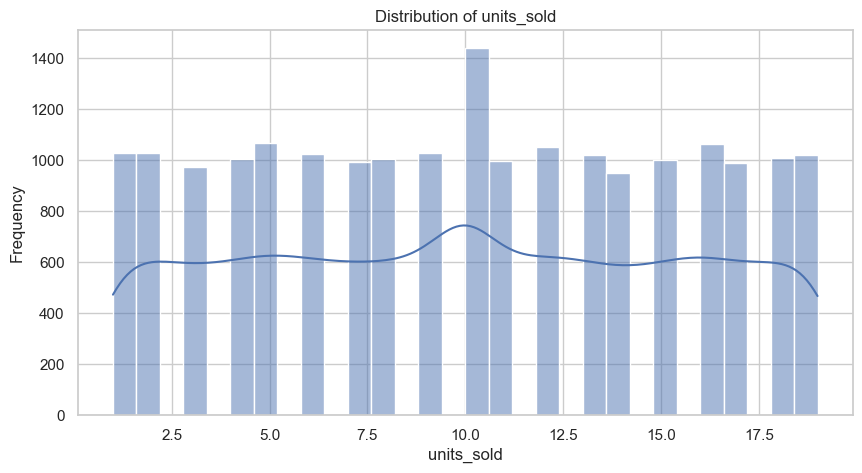

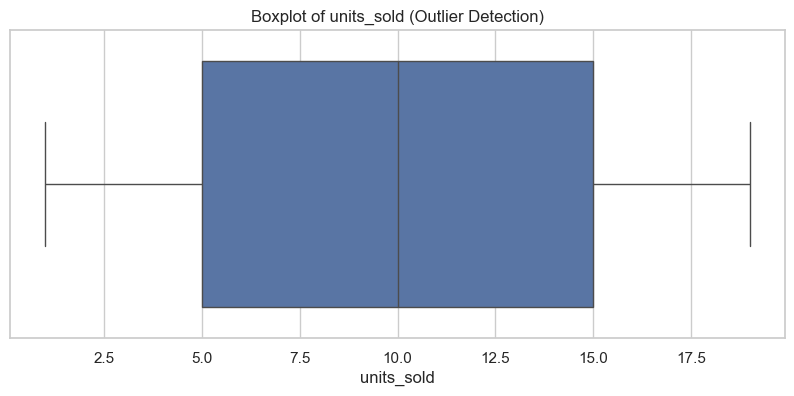

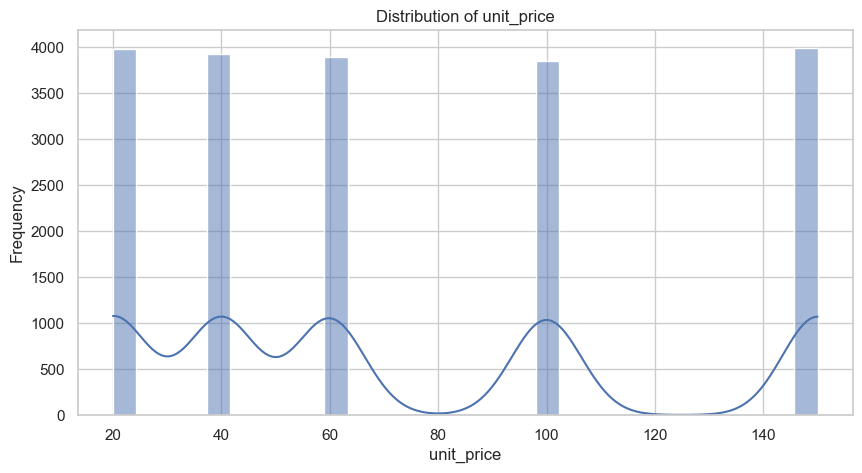

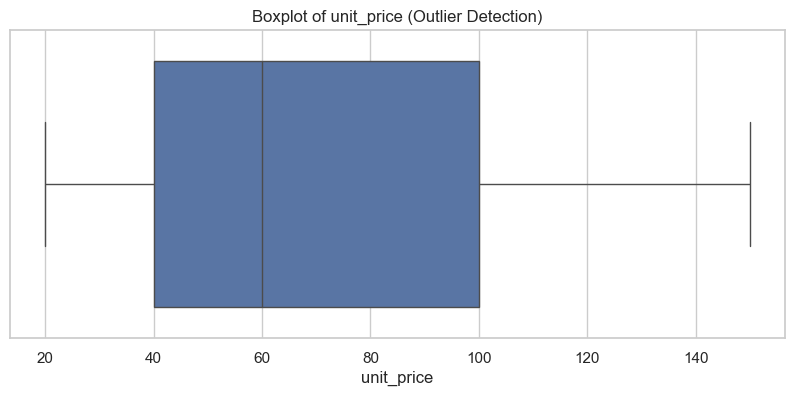

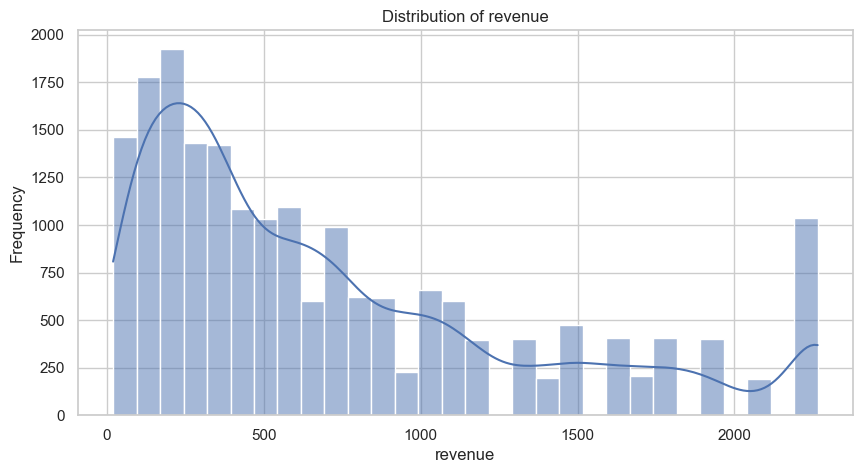

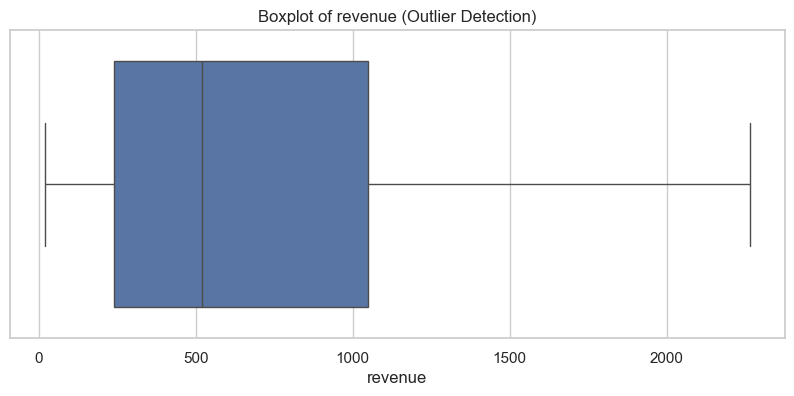


4) CATEGORICAL ANALYSIS
--------------------------------------------------------------------------------


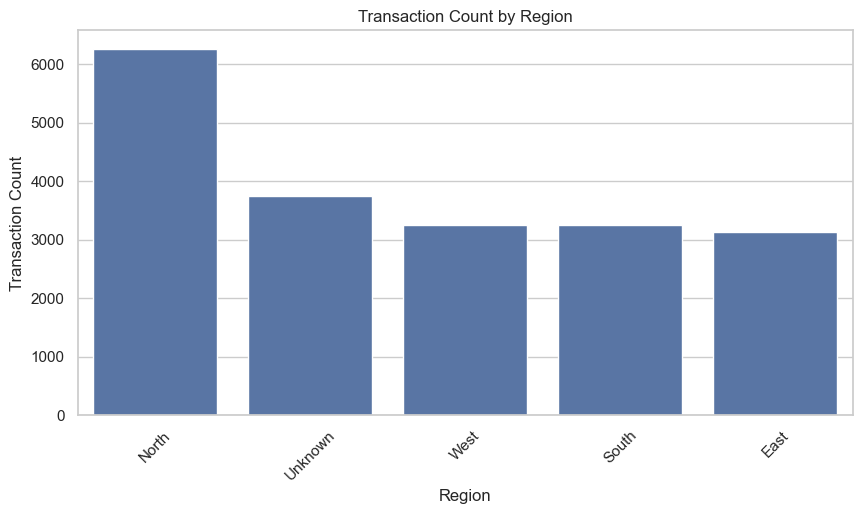

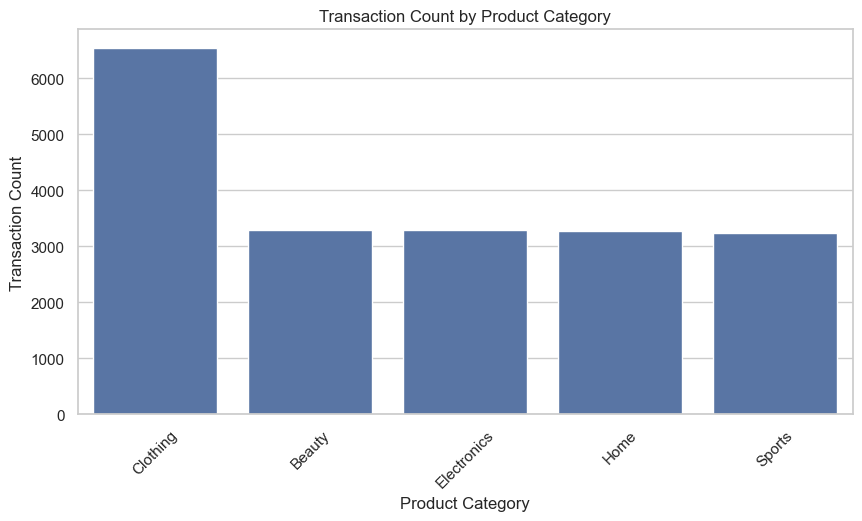

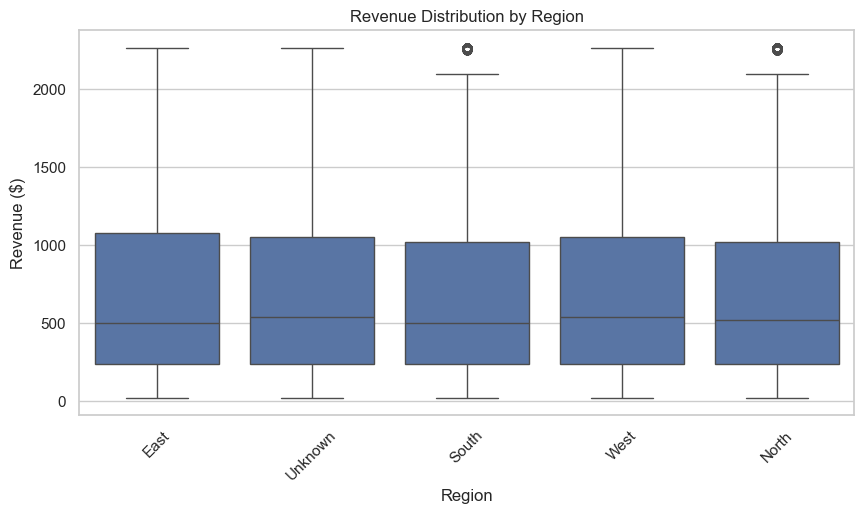

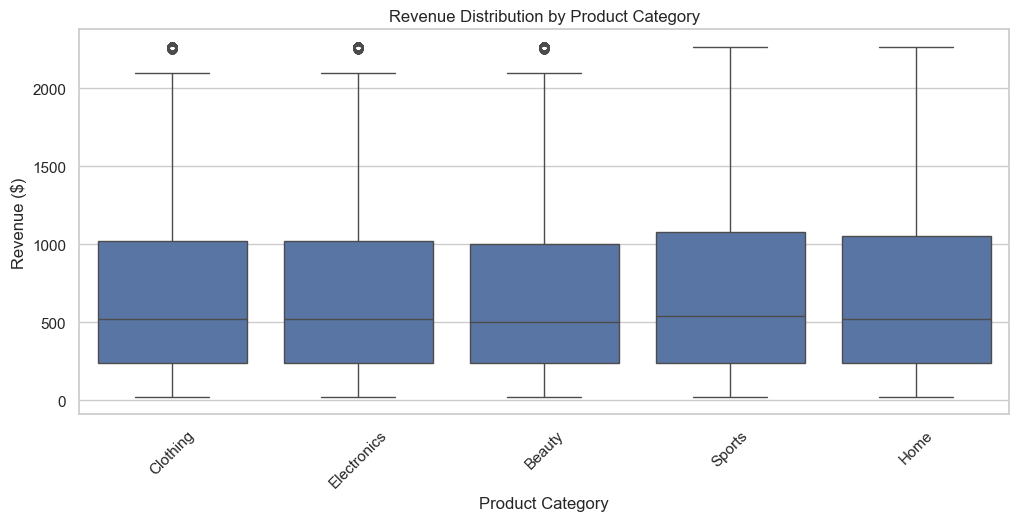


5) OUTLIER DETECTION USING IQR
--------------------------------------------------------------------------------
Revenue outliers detected: 0
Units_sold outliers detected: 0

Sample Revenue Outliers:
Empty DataFrame
Columns: [transaction_date, region, product_category, units_sold, unit_price, revenue]
Index: []

6) RELATIONSHIP ANALYSIS
--------------------------------------------------------------------------------


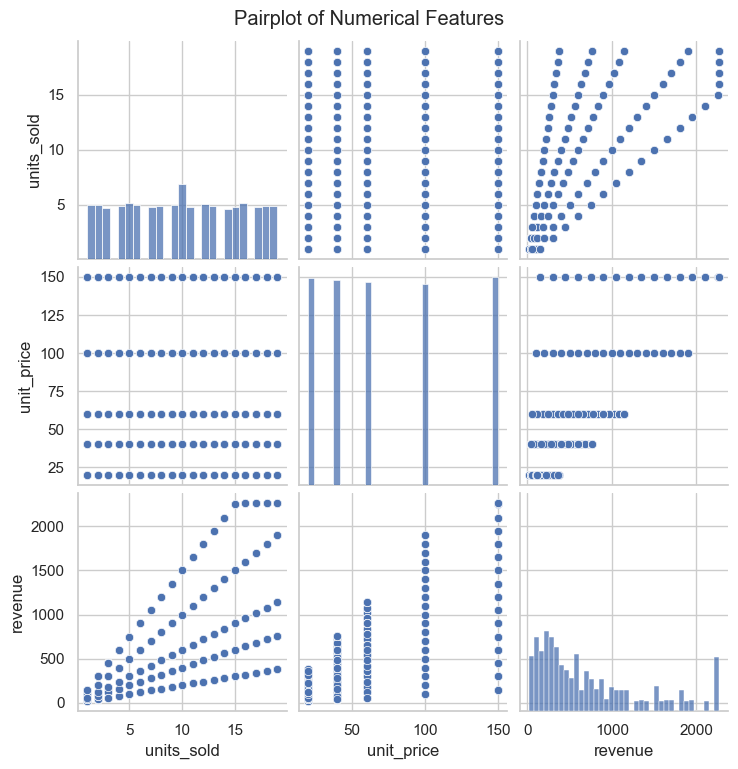

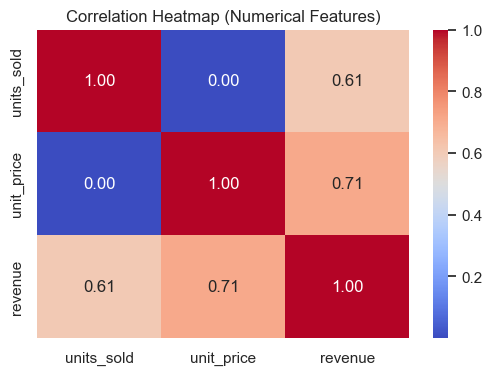


7) HIGH VALUE TRANSACTION ANALYSIS
--------------------------------------------------------------------------------


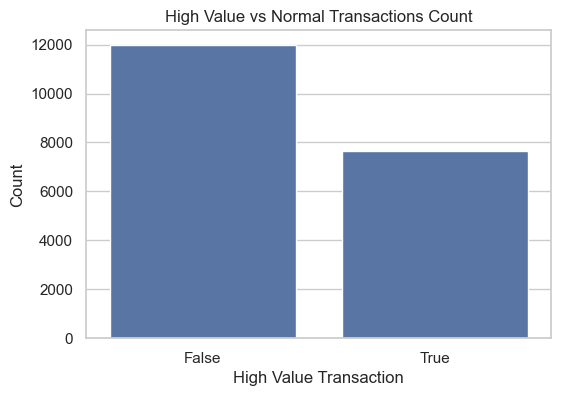

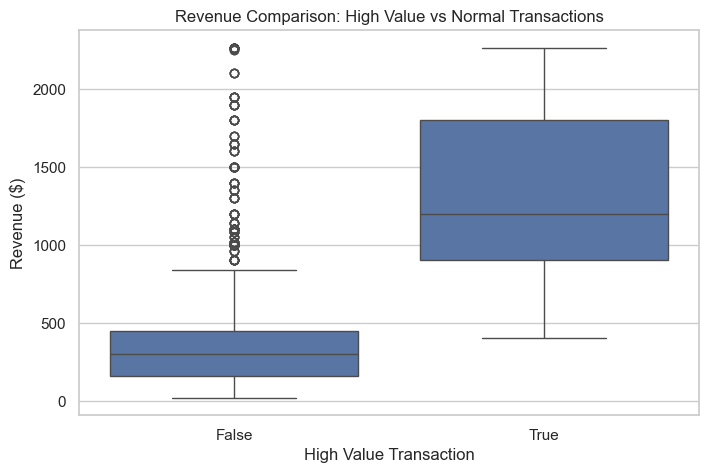


8) TIME SERIES TREND ANALYSIS
--------------------------------------------------------------------------------


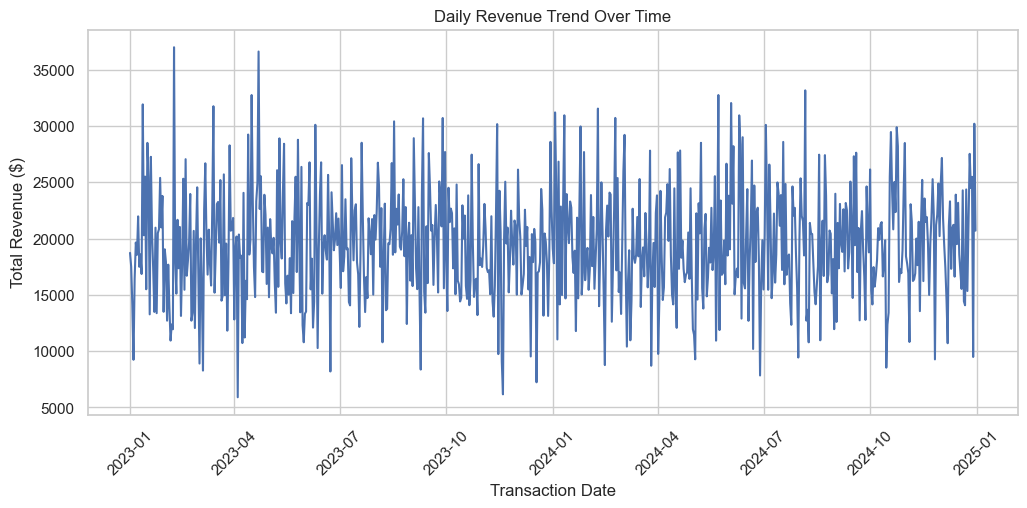

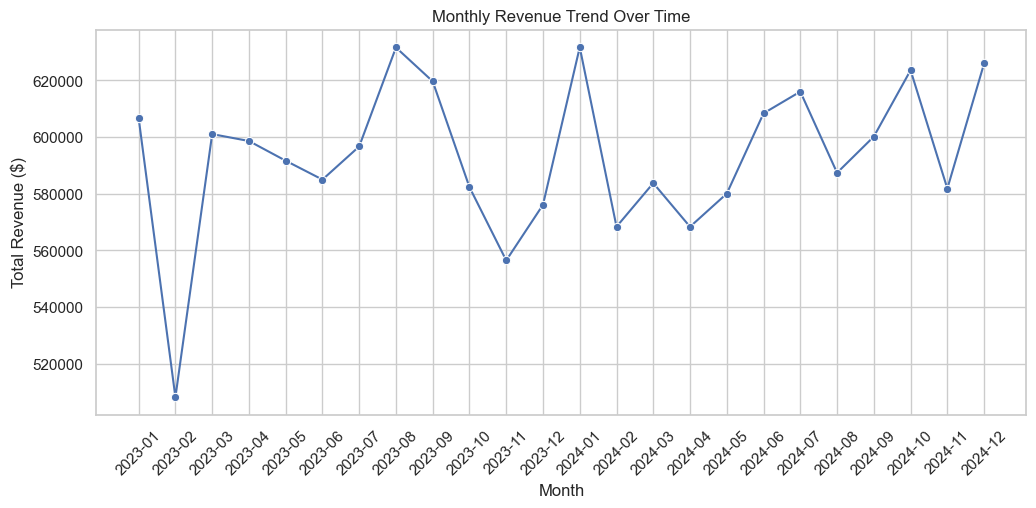

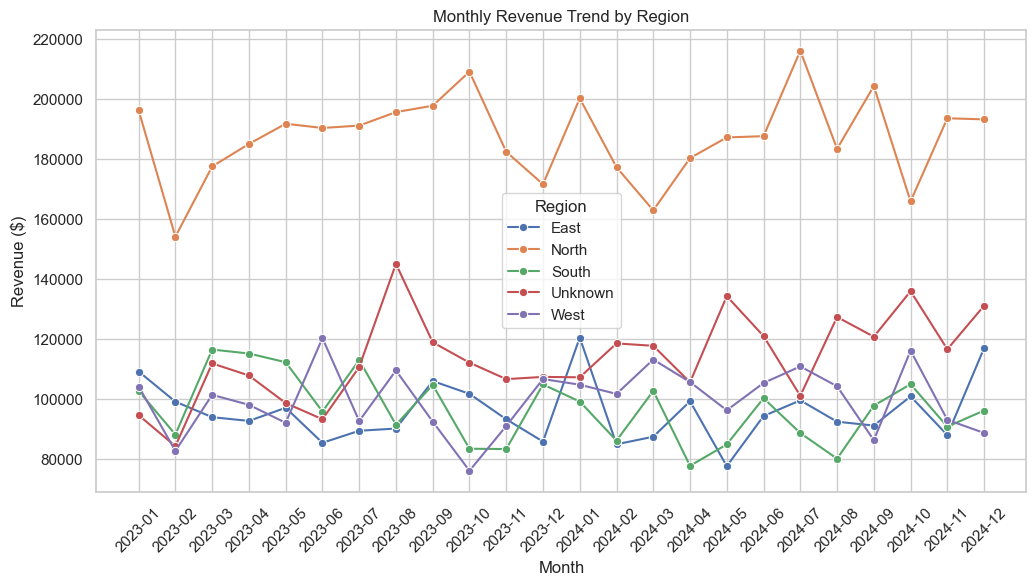

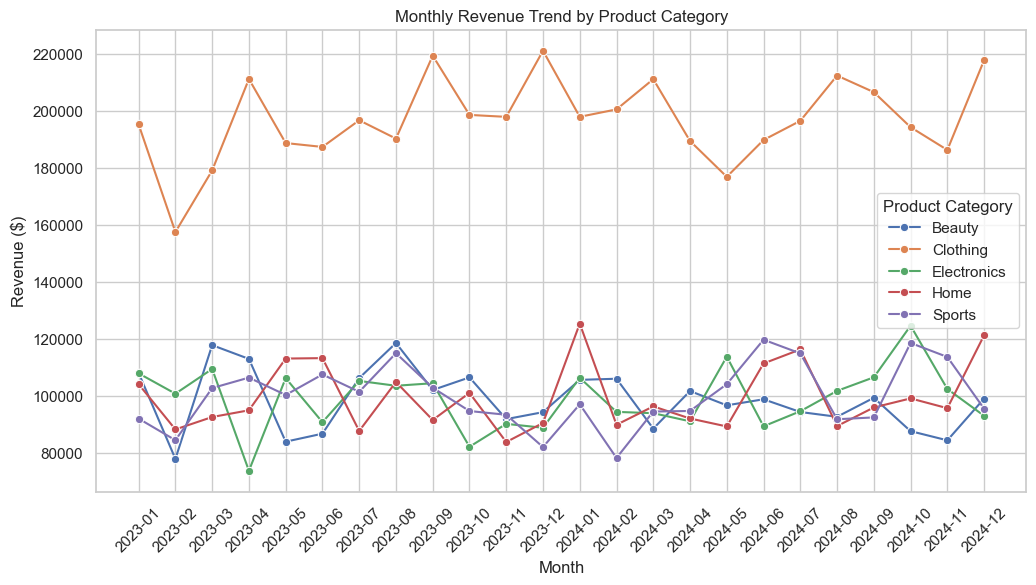


11) TOP PERFORMERS SUMMARY
--------------------------------------------------------------------------------

Top 5 Regions by Total Revenue:
region
North      4492940
Unknown    2727625
West       2392670
South      2320110
East       2296220
Name: revenue, dtype: int64

Top 5 Product Categories by Total Revenue:
product_category
Clothing       4719430
Sports         2394955
Home           2384590
Electronics    2371980
Beauty         2358610
Name: revenue, dtype: int64

Top 5 Customers by Total Spend:
customer_id
2262    19030
2003    18520
2594    18185
2782    18165
1356    18125
Name: revenue, dtype: int64


In [5]:
sns.set(style="whitegrid")

print("\n" + "=" * 80)
print("EDA REPORT")
print("=" * 80)
print("\n1) DATASET OVERVIEW")
print("-" * 80)
print(df_clean.info())

print("\nFirst 5 Rows:")
print(df_clean.head())
print("\n2) SUMMARY STATISTICS")
print("-" * 80)

print("\nNumerical Summary:")
print(df_clean.describe())

print("\nCategorical Summary:")
print(df_clean.describe(include=["object"]))
print("\n3) DISTRIBUTION ANALYSIS (NUMERICAL FEATURES)")
print("-" * 80)

numeric_cols = ["units_sold", "unit_price", "revenue"]

for col in numeric_cols:
    plt.figure(figsize=(10, 5))
    sns.histplot(df_clean[col], bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df_clean[col])
    plt.title(f"Boxplot of {col} (Outlier Detection)")
    plt.xlabel(col)
    plt.show()

print("\n4) CATEGORICAL ANALYSIS")
print("-" * 80)

# transaction count by region
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x="region", order=df_clean["region"].value_counts().index)
plt.title("Transaction Count by Region")
plt.xlabel("Region")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

# transaction count by product category
plt.figure(figsize=(10, 5))
sns.countplot(data=df_clean, x="product_category", order=df_clean["product_category"].value_counts().index)
plt.title("Transaction Count by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Transaction Count")
plt.xticks(rotation=45)
plt.show()

# revenue distribution by region
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="region", y="revenue")
plt.title("Revenue Distribution by Region")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

# revenue distribution by category
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x="product_category", y="revenue")
plt.title("Revenue Distribution by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

print("\n5) OUTLIER DETECTION USING IQR")
print("-" * 80)

def detect_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]
    return outliers

revenue_outliers = detect_outliers_iqr(df_clean, "revenue")
units_outliers = detect_outliers_iqr(df_clean, "units_sold")

print(f"Revenue outliers detected: {revenue_outliers.shape[0]}")
print(f"Units_sold outliers detected: {units_outliers.shape[0]}")

print("\nSample Revenue Outliers:")
print(revenue_outliers[["transaction_date", "region", "product_category", "units_sold", "unit_price", "revenue"]].head())

print("\n6) RELATIONSHIP ANALYSIS")
print("-" * 80)


sns.pairplot(df_clean[numeric_cols])
plt.suptitle("Pairplot of Numerical Features", y=1.02)
plt.show()
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Numerical Features)")
plt.show()


print("\n7) HIGH VALUE TRANSACTION ANALYSIS")
print("-" * 80)

plt.figure(figsize=(6, 4))
sns.countplot(data=df_clean, x="high_value")
plt.title("High Value vs Normal Transactions Count")
plt.xlabel("High Value Transaction")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_clean, x="high_value", y="revenue")
plt.title("Revenue Comparison: High Value vs Normal Transactions")
plt.xlabel("High Value Transaction")
plt.ylabel("Revenue ($)")
plt.show()

print("\n8) TIME SERIES TREND ANALYSIS")
print("-" * 80)

#datetime format
df_clean["transaction_date"] = pd.to_datetime(df_clean["transaction_date"])
# daily revenue trend
daily_revenue = df_clean.groupby("transaction_date")["revenue"].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_revenue, x="transaction_date", y="revenue")
plt.title("Daily Revenue Trend Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()
# monthly revenue trend
df_clean["month"] = df_clean["transaction_date"].dt.to_period("M")
monthly_revenue = df_clean.groupby("month")["revenue"].sum().reset_index()
monthly_revenue["month"] = monthly_revenue["month"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x="month", y="revenue", marker="o")
plt.title("Monthly Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()

monthly_region_revenue = df_clean.groupby(["month", "region"])["revenue"].sum().reset_index()
monthly_region_revenue["month"] = monthly_region_revenue["month"].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_region_revenue, x="month", y="revenue", hue="region", marker="o")
plt.title("Monthly Revenue Trend by Region")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.show()


monthly_category_revenue = df_clean.groupby(["month", "product_category"])["revenue"].sum().reset_index()
monthly_category_revenue["month"] = monthly_category_revenue["month"].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_category_revenue, x="month", y="revenue", hue="product_category", marker="o")
plt.title("Monthly Revenue Trend by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.show()

print("\n11) TOP PERFORMERS SUMMARY")
print("-" * 80)

print("\nTop 5 Regions by Total Revenue:")
print(df_clean.groupby("region")["revenue"].sum().sort_values(ascending=False).head(5))

print("\nTop 5 Product Categories by Total Revenue:")
print(df_clean.groupby("product_category")["revenue"].sum().sort_values(ascending=False).head(5))

print("\nTop 5 Customers by Total Spend:")
print(df_clean.groupby("customer_id")["revenue"].sum().sort_values(ascending=False).head(5))





In [6]:
df_features = df_clean.copy()
original_cols = df_features.columns.tolist()
df_features["transaction_date"] = pd.to_datetime(df_features["transaction_date"], errors="coerce")
df_features["year"] = df_features["transaction_date"].dt.year
df_features["month"] = df_features["transaction_date"].dt.month
df_features["day"] = df_features["transaction_date"].dt.day
df_features["day_of_week"] = df_features["transaction_date"].dt.dayofweek  
df_features["week_of_year"] = df_features["transaction_date"].dt.isocalendar().week.astype(int)
df_features["is_weekend"] = df_features["day_of_week"].isin([5, 6]).astype(int)

df_features["expected_revenue"] = df_features["units_sold"] * df_features["unit_price"]
df_features["revenue_diff"] = df_features["revenue"] - df_features["expected_revenue"]
df_features["revenue_per_unit"] = df_features["revenue"] / df_features["units_sold"]
df_features["revenue_mismatch_flag"] = (abs(df_features["revenue_diff"]) > 0.01).astype(int)
df_features["customer_transaction_count"] = df_features.groupby("customer_id")["customer_id"].transform("count")
df_features["customer_total_units"] = df_features.groupby("customer_id")["units_sold"].transform("sum")
df_features["customer_total_revenue"] = df_features.groupby("customer_id")["revenue"].transform("sum")
df_features["customer_avg_transaction_value"] = (df_features["customer_total_revenue"] / df_features["customer_transaction_count"])
df_features["customer_avg_units"] = (df_features["customer_total_units"] / df_features["customer_transaction_count"])

df_features["region_avg_revenue"] = df_features.groupby("region")["revenue"].transform("mean")
df_features["category_avg_revenue"] = df_features.groupby("product_category")["revenue"].transform("mean")
df_features["region_transaction_count"] = df_features.groupby("region")["region"].transform("count")
df_features["category_transaction_count"] = df_features.groupby("product_category")["product_category"].transform("count")
df_features = df_features.sort_values(["customer_id", "transaction_date"])
df_features["days_since_last_purchase"] = (df_features.groupby("customer_id")["transaction_date"].diff().dt.days)
df_features["days_since_last_purchase"] = df_features["days_since_last_purchase"].fillna(-1)
new_cols = [col for col in df_features.columns if col not in original_cols]

print("FEATURE ENGINEERING")
print(f"Original columns: {len(original_cols)}")
print(f"Total columns now: {df_features.shape[1]}")
print(f"New features added: {len(new_cols)}")

print("\n--- NEW FEATURES CREATED ---")
for i, col in enumerate(new_cols, 1):
    print(f"{i}. {col}")

print("\n" + "=" * 80)
print("FEATURE VALIDATION & USEFULNESS")
print("=" * 80)


print(f"1. TIME-BASED FEATURES CREATED:")
print(f"   - Unique months: {df_features['month'].nunique()}")
print(f"   - Unique weekdays: {df_features['day_of_week'].nunique()}")
print(f"   - Weekend transactions: {df_features['is_weekend'].sum()} rows")


print(f"\n2. REVENUE FEATURES CREATED:")
print(f"   - expected_revenue calculated successfully.")
print(f"   - Revenue mismatches flagged: {df_features['revenue_mismatch_flag'].sum()} anomalies")


print(f"\n3. CUSTOMER BEHAVIOR FEATURES CREATED:")
print(f"   - Unique customers profiled: {df_features['customer_id'].nunique()}")
print(f"   - Max transactions by one customer: {df_features['customer_transaction_count'].max()}")


print(f"\n4. RECENCY FEATURE CREATED:")
print(f"   - Max days_since_last_purchase: {df_features['days_since_last_purchase'].max()}")
print(f"   - First purchases marked with -1: {(df_features['days_since_last_purchase'] == -1).sum()} rows")

print("\n--- SAMPLE OF ENGINEERED DATASET ---")
display(df_features[[
    "transaction_date", "customer_id", "region", "product_category",
    "month", "day_of_week", "is_weekend",
    "customer_transaction_count", "expected_revenue",
    "revenue_mismatch_flag", "days_since_last_purchase"
]].head(10))

print("\n" + "=" * 80)
print("DATA READY FOR PREDICTIVE MODELING!")
print("=" * 80)

FEATURE ENGINEERING
Original columns: 11
Total columns now: 30
New features added: 19

--- NEW FEATURES CREATED ---
1. year
2. day
3. day_of_week
4. week_of_year
5. is_weekend
6. expected_revenue
7. revenue_diff
8. revenue_per_unit
9. revenue_mismatch_flag
10. customer_transaction_count
11. customer_total_units
12. customer_total_revenue
13. customer_avg_transaction_value
14. customer_avg_units
15. region_avg_revenue
16. category_avg_revenue
17. region_transaction_count
18. category_transaction_count
19. days_since_last_purchase

FEATURE VALIDATION & USEFULNESS
1. TIME-BASED FEATURES CREATED:
   - Unique months: 12
   - Unique weekdays: 7
   - Weekend transactions: 5701 rows

2. REVENUE FEATURES CREATED:
   - expected_revenue calculated successfully.
   - Revenue mismatches flagged: 837 anomalies

3. CUSTOMER BEHAVIOR FEATURES CREATED:
   - Unique customers profiled: 2000
   - Max transactions by one customer: 22

4. RECENCY FEATURE CREATED:
   - Max days_since_last_purchase: 529.0
   

,transaction_date,customer_id,region,product_category,month,day_of_week,is_weekend,customer_transaction_count,expected_revenue,revenue_mismatch_flag,days_since_last_purchase
5258,2023-07-15,1000,South,Electronics,7,5,1,13,150,0,-1.0
7429,2023-10-03,1000,North,Clothing,10,1,0,13,750,0,80.0
8551,2023-11-14,1000,East,Clothing,11,1,0,13,320,0,42.0
8659,2023-11-19,1000,North,Beauty,11,6,1,13,400,0,5.0
9353,2023-12-15,1000,South,Home,12,4,0,13,1080,0,26.0
9422,2023-12-19,1000,Unknown,Beauty,12,1,0,13,200,0,4.0
13898,2024-06-04,1000,North,Electronics,6,1,0,13,600,0,168.0
16112,2024-08-24,1000,Unknown,Clothing,8,5,1,13,700,0,81.0
16898,2024-09-22,1000,East,Electronics,9,6,1,13,600,0,29.0
17939,2024-10-29,1000,West,Beauty,10,1,0,13,300,0,37.0



DATA READY FOR PREDICTIVE MODELING!


### 5. VISUALIZATION:

---
[CONTEXT]
You are a data analyst creating visualizations for business reporting.

[TASK]
Create visualizations to explore revenue distribution, compare performance across regions and product categories, and analyze revenue trends over time using transaction_date.

[DATA]
DataFrame: df_clean

[OUTPUT]
Generate Python code using seaborn and matplotlib. Include clear charts with titles, labels, and brief explanations.

[CONSTRAINTS]
Keep visualizations simple, clear, and presentation-ready.

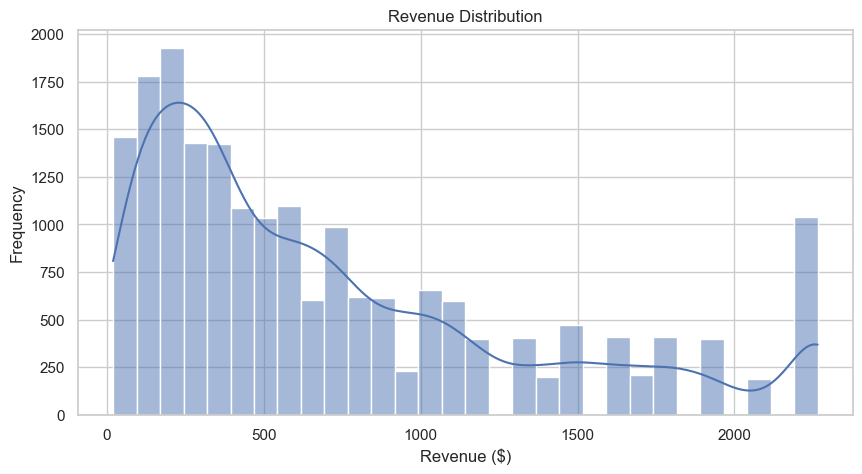

Explanation: This plot shows the distribution of revenue values.
If the distribution is right-skewed, it means a small number of transactions generate very high revenue.



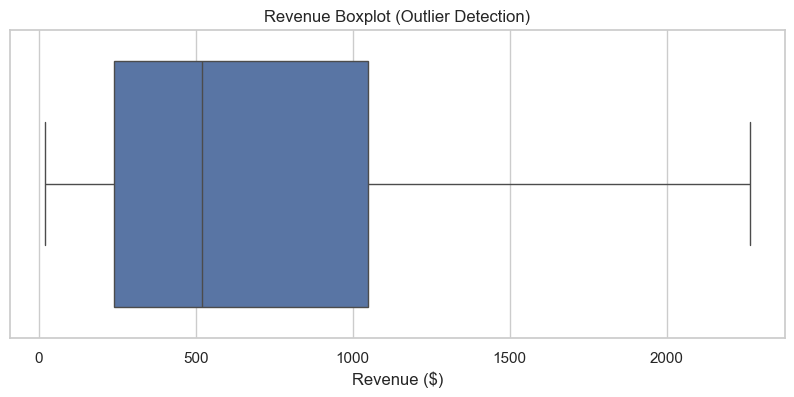

Explanation: The boxplot helps detect unusually high revenue transactions (outliers).
These outliers may represent bulk purchases, promotions, or potential data errors.



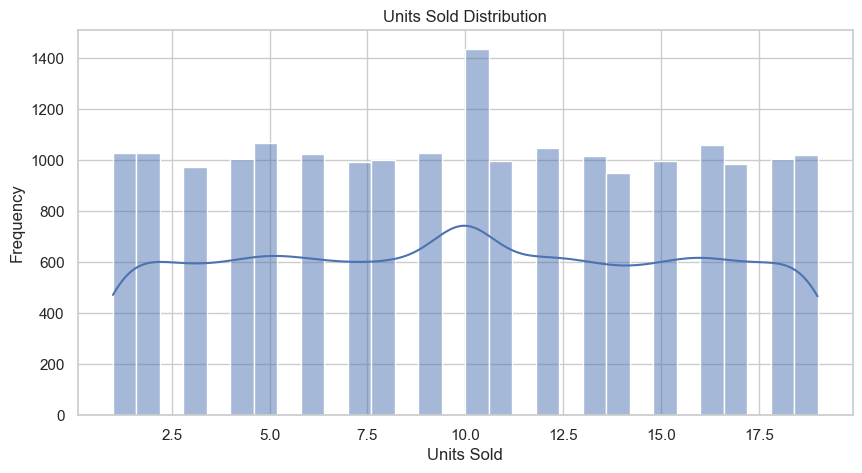

Explanation: This chart shows how many units are sold per transaction.
High values may indicate bulk buying behavior.



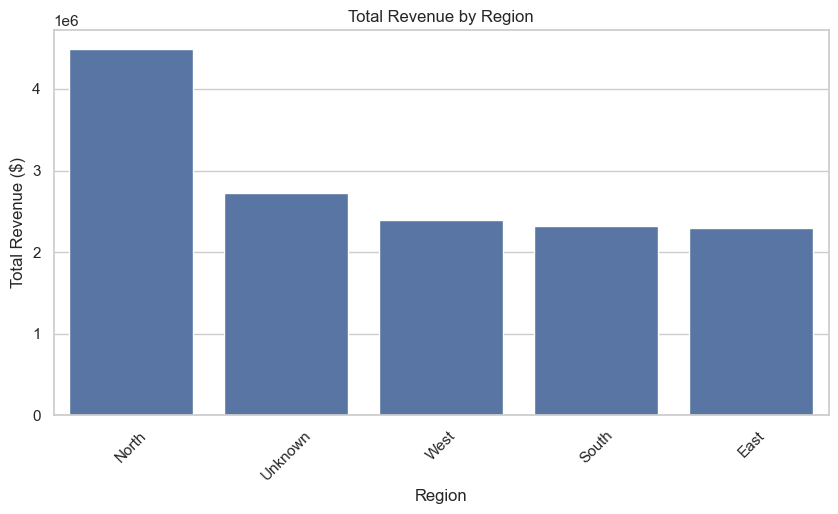

Explanation: This chart compares the total revenue generated by each region.
Regions with the highest bars contribute most to overall sales.



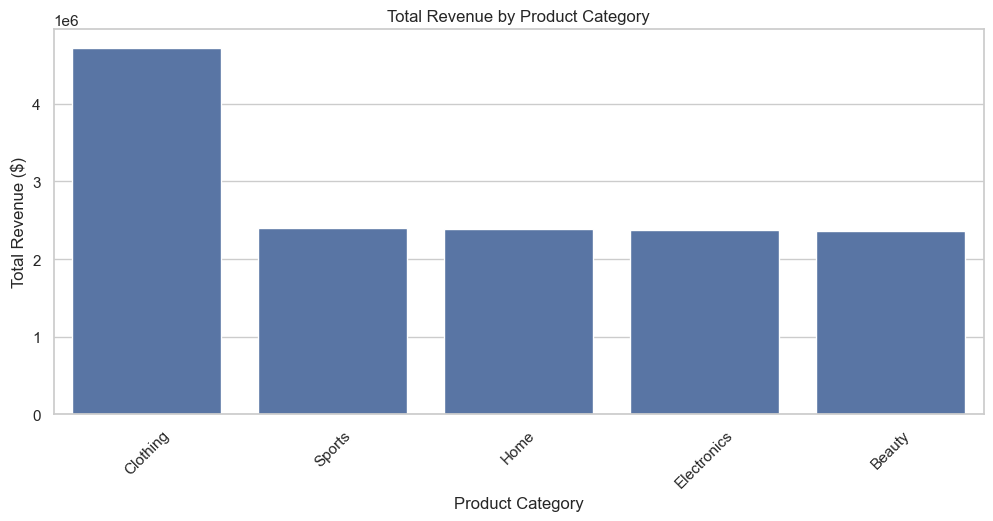

Explanation: This chart shows which product categories generate the highest revenue.
It helps identify best-selling categories and business focus areas.



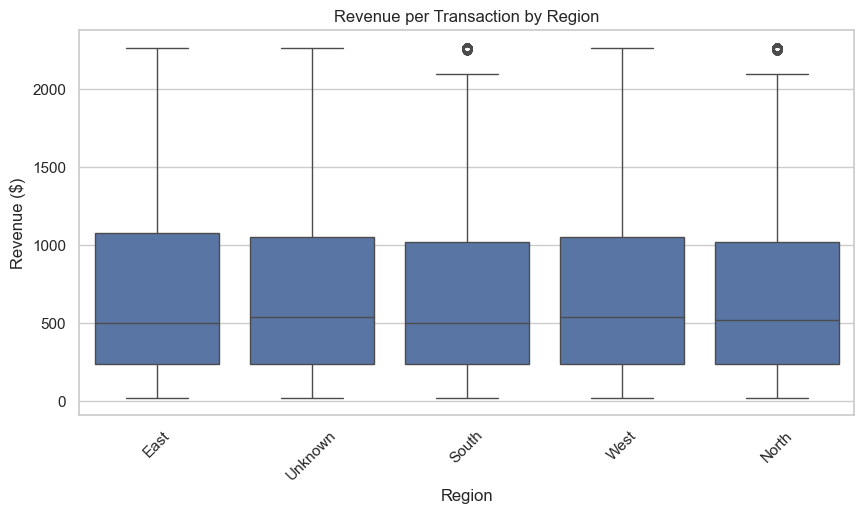

Explanation: This plot compares transaction revenue distribution across regions.
Higher medians indicate regions with higher-value purchases.



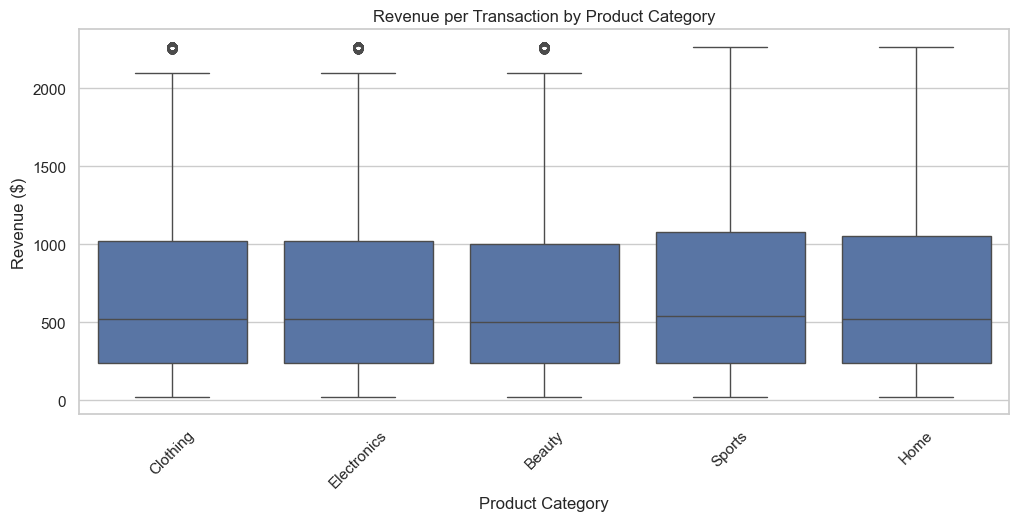

Explanation: This chart compares revenue distribution across product categories.
Categories with higher medians likely contain premium products.



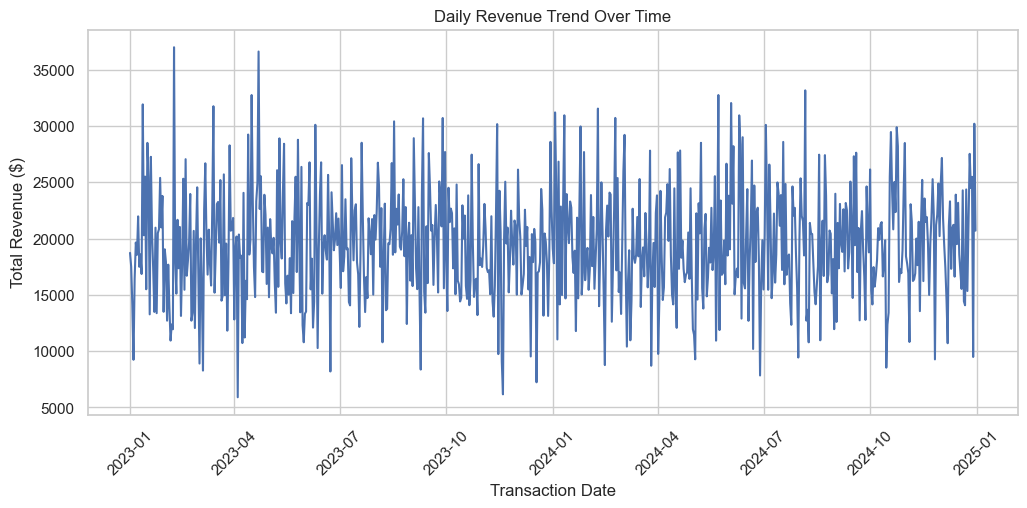

Explanation: This plot shows total revenue trends over time (daily).
Spikes may indicate promotions, seasonal demand, or bulk customer activity.



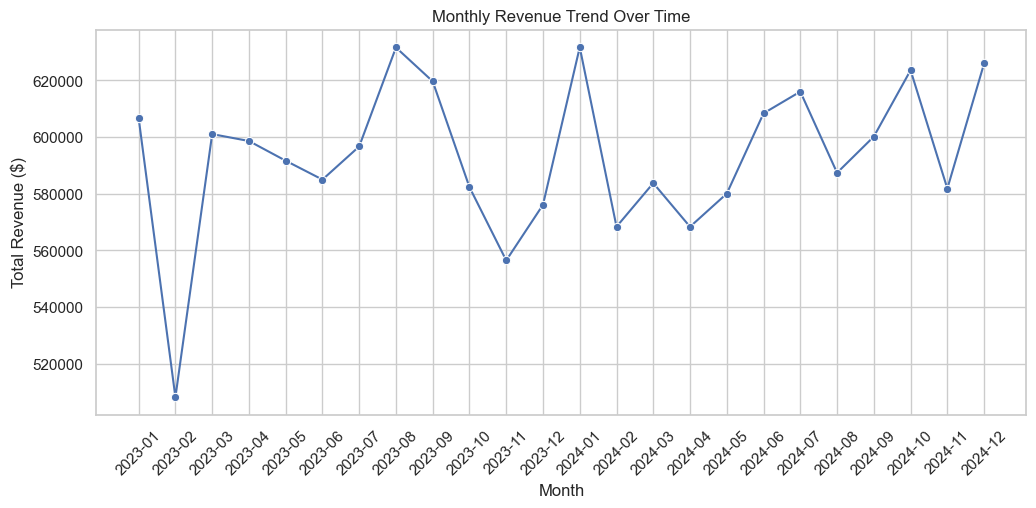

Explanation: Monthly trends provide a smoother view of performance and help identify seasonality.



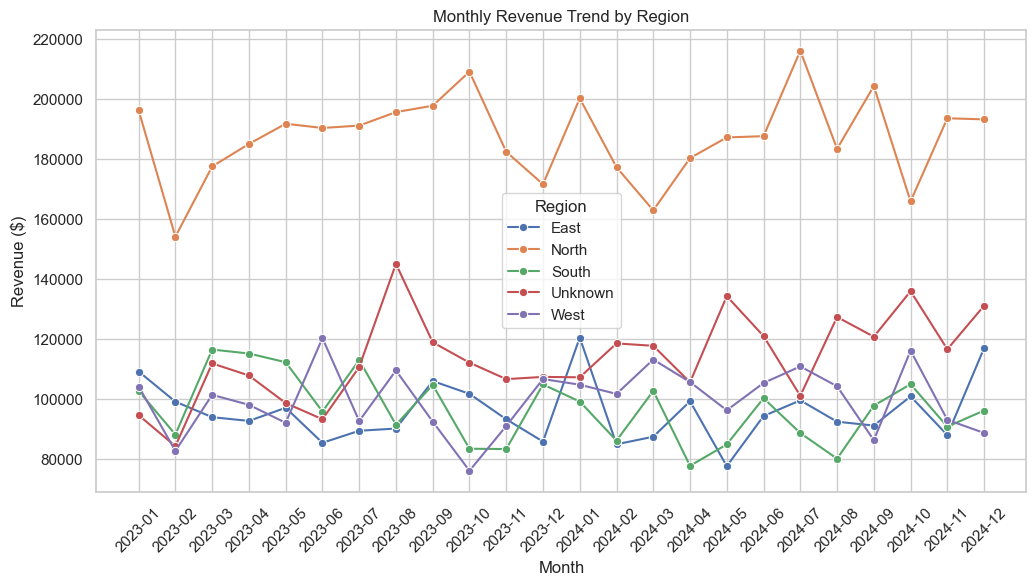

Explanation: This chart compares monthly revenue trends across regions.
It highlights which regions are improving or declining over time.



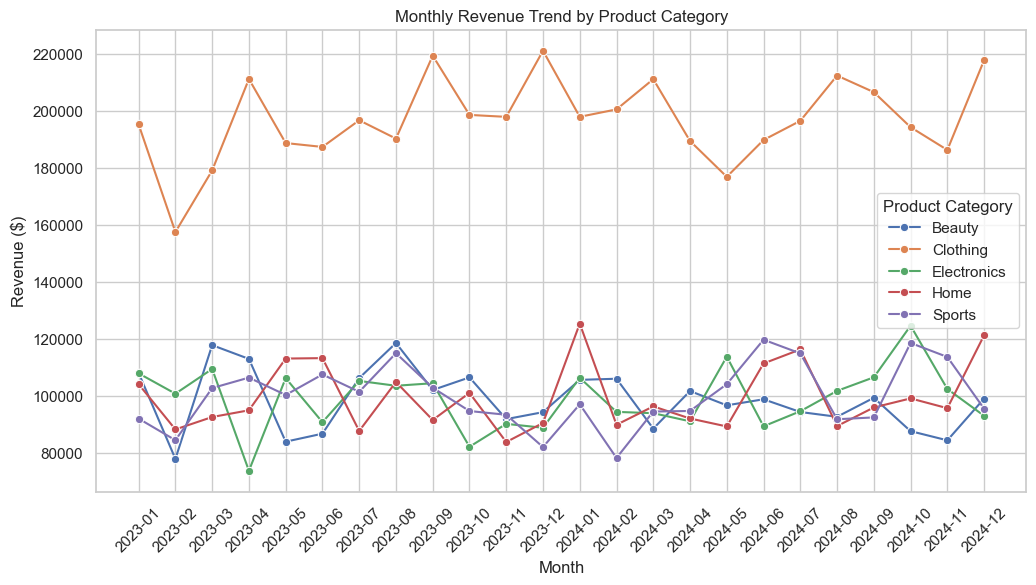

Explanation: This chart compares category performance over time.
It helps identify seasonal categories and categories with consistent growth.

Total transactions visualized: 19656
Total regions analyzed: 5
Total product categories analyzed: 5
Date range: 2023-01-01 00:00:00 to 2024-12-31 00:00:00


In [7]:
sns.set(style="whitegrid")
df_clean["transaction_date"] = pd.to_datetime(df_clean["transaction_date"], errors="coerce")


#revenue Distribution 
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["revenue"], bins=30, kde=True)
plt.title("Revenue Distribution")
plt.xlabel("Revenue ($)")
plt.ylabel("Frequency")
plt.show()

print("Explanation: This plot shows the distribution of revenue values.")
print("If the distribution is right-skewed, it means a small number of transactions generate very high revenue.\n")


#revenu outlier
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_clean["revenue"])
plt.title("Revenue Boxplot (Outlier Detection)")
plt.xlabel("Revenue ($)")
plt.show()
print("Explanation: The boxplot helps detect unusually high revenue transactions (outliers).")
print("These outliers may represent bulk purchases, promotions, or potential data errors.\n")


#unit sold dist 
plt.figure(figsize=(10, 5))
sns.histplot(df_clean["units_sold"], bins=30, kde=True)
plt.title("Units Sold Distribution")
plt.xlabel("Units Sold")
plt.ylabel("Frequency")
plt.show()
print("Explanation: This chart shows how many units are sold per transaction.")
print("High values may indicate bulk buying behavior.\n")


#region performance
region_revenue = df_clean.groupby("region")["revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
sns.barplot(x=region_revenue.index, y=region_revenue.values)
plt.title("Total Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()
print("Explanation: This chart compares the total revenue generated by each region.")
print("Regions with the highest bars contribute most to overall sales.\n")


#product category performance
category_revenue = df_clean.groupby("product_category")["revenue"].sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
sns.barplot(x=category_revenue.index, y=category_revenue.values)
plt.title("Total Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()
print("Explanation: This chart shows which product categories generate the highest revenue.")
print("It helps identify best-selling categories and business focus areas.\n")



#avg revenue /transaction by region
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_clean, x="region", y="revenue")
plt.title("Revenue per Transaction by Region")
plt.xlabel("Region")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()

print("Explanation: This plot compares transaction revenue distribution across regions.")
print("Higher medians indicate regions with higher-value purchases.\n")


#avg revenue/transaction by product category
plt.figure(figsize=(12, 5))
sns.boxplot(data=df_clean, x="product_category", y="revenue")
plt.title("Revenue per Transaction by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.show()
print("Explanation: This chart compares revenue distribution across product categories.")
print("Categories with higher medians likely contain premium products.\n")


#daily revenue /time
daily_revenue = df_clean.groupby("transaction_date")["revenue"].sum().reset_index()

plt.figure(figsize=(12, 5))
sns.lineplot(data=daily_revenue, x="transaction_date", y="revenue")
plt.title("Daily Revenue Trend Over Time")
plt.xlabel("Transaction Date")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()

print("Explanation: This plot shows total revenue trends over time (daily).")
print("Spikes may indicate promotions, seasonal demand, or bulk customer activity.\n")

#monthly revenue trend/time
df_clean["month"] = df_clean["transaction_date"].dt.to_period("M")
monthly_revenue = df_clean.groupby("month")["revenue"].sum().reset_index()
monthly_revenue["month"] = monthly_revenue["month"].astype(str)

plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_revenue, x="month", y="revenue", marker="o")
plt.title("Monthly Revenue Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=45)
plt.show()

print("Explanation: Monthly trends provide a smoother view of performance and help identify seasonality.\n")


#trend comparison by region
monthly_region_revenue = df_clean.groupby(["month", "region"])["revenue"].sum().reset_index()
monthly_region_revenue["month"] = monthly_region_revenue["month"].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_region_revenue, x="month", y="revenue", hue="region", marker="o")
plt.title("Monthly Revenue Trend by Region")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend(title="Region")
plt.show()

print("Explanation: This chart compares monthly revenue trends across regions.")
print("It highlights which regions are improving or declining over time.\n")


#tredn compariosn by category
monthly_category_revenue = df_clean.groupby(["month", "product_category"])["revenue"].sum().reset_index()
monthly_category_revenue["month"] = monthly_category_revenue["month"].astype(str)

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_category_revenue, x="month", y="revenue", hue="product_category", marker="o")
plt.title("Monthly Revenue Trend by Product Category")
plt.xlabel("Month")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=45)
plt.legend(title="Product Category")
plt.show()

print("Explanation: This chart compares category performance over time.")
print("It helps identify seasonal categories and categories with consistent growth.\n")



print(f"Total transactions visualized: {df_clean.shape[0]}")
print(f"Total regions analyzed: {df_clean['region'].nunique()}")
print(f"Total product categories analyzed: {df_clean['product_category'].nunique()}")
print(f"Date range: {df_clean['transaction_date'].min()} to {df_clean['transaction_date'].max()}")



# Key Business Insights (Based on EDA + Visualizations)

---

## Insight 1: Revenue is right-skewed → few transactions generate most revenue

### What we observed (EDA Evidence):
- The revenue histogram shows most transactions fall in the low-to-mid revenue range.
- The revenue boxplot confirms strong outliers (very high revenue transactions).

### Possible business drivers:
- Some customers are making bulk purchases (high `units_sold`).
- Certain categories (like Electronics) may contain expensive products.
- Large orders could be driven by promotions, business clients, or wholesale buyers.

### Business takeaway (Actionable):
- Revenue is heavily dependent on a small segment of customers/orders.
- The company should protect and retain these high-value buyers through loyalty programs or VIP offers.

### Follow-up / ML use case:
- Predict high-value transactions using customer behavior features.
- Identify the profile of top 5% spenders.

---

## Insight 2: Region performance differs significantly

### What we observed:
- Total revenue by region (bar chart) shows clear differences between regions.
- Revenue per transaction by region (boxplot) suggests some regions have higher median transaction value.

### Possible business drivers:
- Stronger customer purchasing power in specific regions.
- Better store performance / logistics / product availability.
- Regional promotions or marketing effectiveness.
- Population density and demand differences.

### Business takeaway (Actionable):
- High-performing regions should be prioritized for:
  - inventory expansion
  - targeted campaigns
  - premium product availability
- Low-performing regions require investigation: is it low demand or weak product strategy?

### Follow-up analysis / ML use case:
- Regional revenue forecasting.
- Promotion response prediction by region.

---

## Insight 3: Product categories show different sales behavior

### What we observed:
- Revenue by product category chart shows some categories generate higher revenue than others.
- Revenue per transaction boxplot shows categories differ in transaction value.

### Possible business drivers:
- Electronics likely has higher unit price.
- Beauty and Clothing may generate frequent but smaller purchases.
- Sports/Home may have occasional high-ticket items.

### Business takeaway (Actionable):
- Categories should not be treated the same:
  - High-ticket categories → focus on upselling + premium campaigns.
  - Low-ticket categories → focus on retention + bundle offers.

### Follow-up analysis / ML use case:
- Category-level demand forecasting.
- Recommendation system (predict next category purchase).

---

## Insight 4: Revenue trend over time shows spikes and seasonality

### What we observed:
- Daily revenue trend shows noticeable spikes.
- Monthly revenue trend is smoother and suggests certain periods perform better than others.

### Possible business drivers:
- Promotions / discount campaigns.
- Seasonal demand patterns.
- Special holidays (sales events).
- Stock availability affecting dips.

### Anomaly to highlight:
- Some sudden spikes may represent bulk orders or unusual customer behavior.

### Business takeaway (Actionable):
- Identify which days/months drive spikes → replicate those strategies.
- Build seasonal inventory planning.

### Follow-up analysis / ML use case:
- Time-series forecasting model for monthly revenue.
- Promotion uplift analysis.

---

## Insight 5: Revenue is strongly driven by units_sold and unit_price

### What we observed:
- Correlation heatmap shows strong positive correlation between revenue and:
  - `units_sold`
  - `unit_price`

### Possible business drivers:
- Higher sales volume increases revenue directly.
- Pricing strategy has direct impact on total revenue.

### Business takeaway (Actionable):
Revenue growth can come from two directions:
- increasing basket size (bundling / cross-selling)
- increasing pricing power (premium products / optimized pricing)

### Follow-up analysis / ML use case:
- Price sensitivity modeling.
- Predict demand based on pricing.

---

# Anomalie & Unusual Pattern

---

## Revenue mismatch issue (Potential Risk)

### Observation:
Even though revenue was recalculated in cleaning, originally:
- revenue values may not have matched `units_sold × unit_price`.

### Possible causes:
- Discounts applied but not recorded.
- Refunds/returns missing.
- Data entry errors.

### Business risk:
- Finance reporting could be inaccurate if revenue mismatches are real business events.

---

# Recommended Next Steps (High Business Value)

## 1. RFM(Recency, Frequency, Monetary) Analysis for Customer Segmentation
Segment customers into:
- Loyal high spenders
- New customers
- Lost customers
- Frequent low spenders

**Business benefit:** Better targeting + retention strategy

---

## 2. High-Value Customer Prediction Model
Use features like:
- transaction frequency
- customer_total_revenue
- recency
- category behavior

**Business benefit:** Target customers before churn and increase lifetime value

---

## 3. Revenue Forecasting
Forecast monthly revenue using time-based patterns.

**Business benefit:** Inventory planning, staffing, budgeting

---

## 4. Investigate Revenue Spikes
Drill down into:
- top revenue days
- top customers
- region-category combinations

**Business benefit:** Replicate successful events and campaigns

---

#  Stakeholder Summary (Executive Level)

- Revenue is dominated by a small number of high-value transactions.
- Regions differ strongly in revenue performance → strategy must be region-specific.
- Categories have different purchasing patterns → require tailored marketing.
- Time trends show spikes and seasonality → forecasting is valuable.